In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
magic_epoch = 11

In [3]:
'''def getStuff(s,folder="fixed_aug", l=0,h=10):
    msg = folder + "/" + s + "_accs"
    for i in range(l,h):
        exec('df' + str(i) + ' = pd.read_csv(msg + str(i) + ".csv", index_col=0)')

    df = pd.DataFrame(data=[eval('df' + str(i) + '.iloc[1]') for i in range(l,h)])
    mean = df.mean(axis=0)
    std = df.std(axis=0)
    return mean, std'''

'def getStuff(s,folder="fixed_aug", l=0,h=10):\n    msg = folder + "/" + s + "_accs"\n    for i in range(l,h):\n        exec(\'df\' + str(i) + \' = pd.read_csv(msg + str(i) + ".csv", index_col=0)\')\n\n    df = pd.DataFrame(data=[eval(\'df\' + str(i) + \'.iloc[1]\') for i in range(l,h)])\n    mean = df.mean(axis=0)\n    std = df.std(axis=0)\n    return mean, std'

In [4]:
def getStuff2(s, folder="fixed_aug", l=0, h=10):
    msg = folder + "/" + s + "_accs"

    # Read all CSVs into a list
    dfs = [
        pd.read_csv(f"{msg}{i}.csv", index_col=0)
        for i in range(l, h)
    ]

    # Extract the row at magic_epoch from each df
    df = pd.DataFrame([d.iloc[magic_epoch] for d in dfs])

    median = df.median(axis=0)
    Q3 = df.quantile(0.75)
    Q1 = df.quantile(0.25)
    iqrO2 = (Q3 - Q1) / 2

    return median, iqrO2, df


In [5]:
def getStuffTimes(s, folder="fixed_aug", l=0, h=10):
    msg = f"{folder}/{s}_times"

    # Load all the CSVs into a list
    dfs = [
        pd.read_csv(f"{msg}{i}.csv", header=None)
        for i in range(l, h)
    ]

    # Extract the first column (column 0) from each df
    df = pd.DataFrame([d[0] for d in dfs])

    # Keep only the first two columns if they exist
    df = df.iloc[:, :2]

    mean = df.mean(axis=0)
    std = df.std(axis=0)
    median = df.median(axis=0)
    Q3 = df.quantile(0.75)
    Q1 = df.quantile(0.25)
    iqrO2 = (Q3 - Q1) / 2

    return mean, std, median, iqrO2

In [6]:
augmeant, augstdt, augmediant, augiqrt = getStuffTimes("aug")
#vanmeant, vanstdt, vanmediant, vaniqrt = getStuffTimes("nosym",folder="nosym")
#symmeant, symstdt, symmediant, symiqrt = getStuffTimes("plsym",folder="plsym")
symaugmeant, symaugstdt, symaugmediant, symaugiqrt = getStuffTimes("symaug",folder="symaug")

In [7]:
base_t = pd.read_csv("summary/base.csv", header=None)
base_terr = pd.read_csv("summary/base_err.csv", header=None)

sym_t = pd.read_csv("summary/sym_ext.csv", header=None)
sym_terr = pd.read_csv("summary/sym_ext_err.csv", header=None)

In [8]:
augmediant

0    18.433107
1    18.990767
dtype: float64

In [9]:
augiqrt

0    0.186703
1    0.499069
dtype: float64

In [10]:
symaugmediant

0    19.324215
1    19.136842
dtype: float64

In [11]:
symaugiqrt

0    0.280185
1    0.392505
dtype: float64

In [12]:
augmedian, augiqr, augdf = getStuff2("aug")
symaugmedian, symaugiqr, symaugdf = getStuff2("symaug",folder="symaug")
#augmean, augstd = getStuff("aug")
canmedian, caniqr, candf = getStuff2("can",folder="can")

In [13]:
base_accs = pd.read_csv("summary/base.csv", header=None)
base_err = pd.read_csv("summary/base_err.csv", header=None)

sym_accs = pd.read_csv("summary/sym_ext.csv", header=None)
sym_err = pd.read_csv("summary/sym_ext_err.csv", header=None)

In [14]:
gammas = [0.0,0.1,0.2,0.25,0.33,0.5,1.0,1.5,1.66,1.75,1.8,1.9,2.0]

In [18]:
canmedian

0    0.94155
1    0.94155
2    0.94155
3    0.94155
4    0.94155
5    0.94155
dtype: float64

In [19]:
caniqr

0    0.004238
1    0.004238
2    0.004238
3    0.004238
4    0.004238
5    0.004238
dtype: float64

In [16]:
augmedian[1:-1]

1     0.96630
2     0.97645
3     0.97715
4     0.97770
5     0.97785
6     0.97805
7     0.97750
8     0.97735
9     0.97730
10    0.97735
11    0.97715
dtype: float64

ValueError: 'x' and 'y' must have the same size

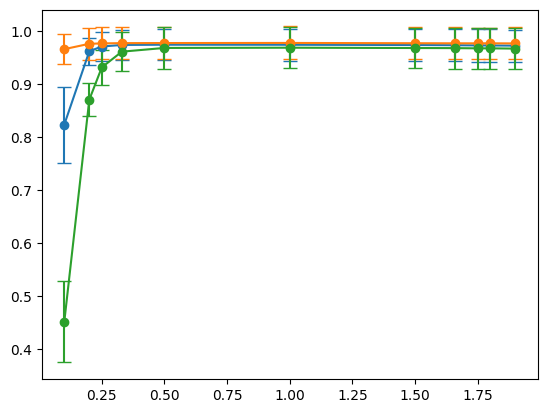

In [15]:
#plt.plot(x='x', y='y', yerr='y_error', kind='line', marker='o', capsize=4)
plt.errorbar(gammas[1:-1],sym_accs.iloc[magic_epoch], yerr=sym_err.iloc[magic_epoch], fmt='-o', capsize=5, label="Symmetry Regularization")
plt.errorbar(gammas[1:-1],augmedian[1:-1], yerr=augiqr[1:-1], capsize=5, fmt='-o', label="Augmentation")
plt.errorbar(gammas[1:-1],base_accs.iloc[magic_epoch], yerr=base_err.iloc[magic_epoch], fmt='-o', capsize=5, label="Baseline")
#plt.errorbar(gammas[1:-1],symaugmedian[1:-1], yerr=symaugiqr[1:-1], capsize=5, fmt='-o', label="Regularization + Augmentation")
plt.errorbar(gammas[1:-1],canmedian[1:-1], yerr=caniqr[1:-1], capsize=5, fmt='-o', label="Canonicalization")
plt.title('Test Accuracy on Gamma-Corrected MNIST Images')
plt.xlabel('Gamma')
plt.ylabel('Accuracy')
plt.legend()
plt.ylim(0.1,1.1)
plt.xlim(0.0,2.1)
#plt.savefig("noname.pdf")
plt.show()

In [11]:
list(augmedian[1:-1])

[0.9662999999999999,
 0.97645,
 0.97715,
 0.9777,
 0.97785,
 0.9780500000000001,
 0.9775,
 0.9773499999999999,
 0.9773000000000001,
 0.9773499999999999,
 0.97715]

In [12]:
list(augiqr[1:-1])

[0.02881250000000002,
 0.02997500000000003,
 0.03015000000000001,
 0.030537499999999995,
 0.030937500000000007,
 0.031112499999999987,
 0.03016249999999998,
 0.030012499999999998,
 0.029737500000000028,
 0.02970000000000006,
 0.030212499999999975]

In [13]:
sym_accs.iloc[magic_epoch]

0     0.82355
1     0.96235
2     0.97130
3     0.97425
4     0.97470
5     0.97460
6     0.97410
7     0.97375
8     0.97335
9     0.97330
10    0.97295
Name: 11, dtype: float64

In [14]:
sym_err.iloc[magic_epoch]

0     0.071850
1     0.025712
2     0.026875
3     0.028375
4     0.029700
5     0.030662
6     0.030600
7     0.030513
8     0.030400
9     0.030437
10    0.030475
Name: 11, dtype: float64

In [15]:
list(symaugmedian[1:-1])

[0.94085,
 0.93955,
 0.9381,
 0.9371,
 0.93635,
 0.9347000000000001,
 0.9331499999999999,
 0.9328000000000001,
 0.9328,
 0.93285,
 0.93255]

In [16]:
list(symaugiqr[1:-1])

[0.03242499999999998,
 0.04083749999999997,
 0.041137499999999994,
 0.041750000000000065,
 0.04231249999999992,
 0.04203750000000006,
 0.04242499999999999,
 0.042200000000000015,
 0.04226249999999998,
 0.04231250000000003,
 0.04223750000000004]

In [18]:
base_accs.iloc[magic_epoch]

0     0.45075
1     0.87095
2     0.93200
3     0.96155
4     0.96860
5     0.96905
6     0.96845
7     0.96825
8     0.96785
9     0.96785
10    0.96735
Name: 11, dtype: float64

In [19]:
base_err.iloc[magic_epoch]

0     0.076675
1     0.030925
2     0.033513
3     0.037275
4     0.039200
5     0.038738
6     0.038525
7     0.038650
8     0.038525
9     0.038475
10    0.038125
Name: 11, dtype: float64